---
subtitle: "Lab 02 - Classification"
jupyter: python3
execute:
  enabled: true
---

<a href="https://colab.research.google.com/github/w4bo/AA2627-unibo-mldm/blob/master/slides/07-modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#

<img src="./img/crispdm_me.svg" class="center-img">

# Modeling

Machine Learning is the science (and art) of programming computers so they can learn from data

> **Machine Learning** is the field of study that gives computers the ability to learn without being explicitly programmed (Arthur Samuel, 1959)

> A computer program is said to **learn** from *experience E with respect to some task T and some performance measure P*, *if its performance on T, as measured by P, improves with experience E* (Tom Mitchell, 1997)


# Under and overfitting

![https://xkcd.com/605/](img/modeling/slides391.png)

# Under and overfitting

![https://xkcd.com/2048/](img/modeling/slides390.png)

# Disclaimer

Machine learning is not just the application of some algorithms to get the best accuracy...

- You need to understand **why** a model is behaving in a certain way!
- Do not stop at the first (good) result, questioning your algorithm/pipeline is essential!
- Do not rely on external code without knowing what the code is doing
    - Remember, if you cannot explain your code the exam is not passed

In [1]:
#| echo: false
#| output: false
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

# Let's train some machine learning models

In [2]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df["species"] = iris.target

X = df.drop("species", axis=1)
y = df["species"]
seed = 42
test_size = 0.2
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed,)


# Models covered in this lecture

Let's see how models behave

- Decision tree
- Random forest
- k-NN

# Decision tree

In [3]:
from sklearn.tree import DecisionTreeClassifier  # Import the model
from sklearn.metrics import accuracy_score

clf = DecisionTreeClassifier(max_depth=2, random_state=seed)  # Instantiate and fit the model (on the training set)
clf.fit(X_train, y_train)  # Train the model
y_pred = clf.predict(X_test)  # Predict new values
accuracy_score(y_test, y_pred)  # Evaluate the model (on the test set)

0.9666666666666667

## Plotting the tree

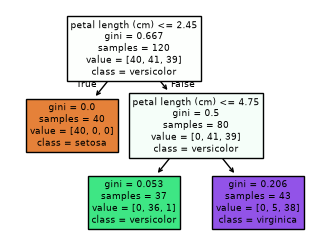

In [4]:
from sklearn.tree import plot_tree
plt.figure(figsize=(4, 3))
plot_tree(clf, feature_names=df.columns, class_names=['setosa', 'versicolor', 'virginica'], filled=True);

## Checking feature relevance

In [5]:
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': clf.feature_importances_})  # Create a DataFrame to display feature importance
feature_importance_df = feature_importance_df.sort_values(['Importance', 'Feature'], ascending=[False, True])  # Sort the DataFrame by importance in descending order
feature_importance_df  # Display the feature importance 

,Feature,Importance
2,petal length (cm),1.0
3,petal width (cm),0.0
0,sepal length (cm),0.0
1,sepal width (cm),0.0


# Feature selection: checking correlations

In [6]:
X_train.corr(method='pearson', numeric_only=True)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.106926,0.862175,0.801480
sepal width (cm),-0.106926,1.000000,-0.432089,-0.369509
petal length (cm),0.862175,-0.432089,1.000000,0.962577
petal width (cm),0.801480,-0.369509,0.962577,1.000000


# `petal` vs `sepal`

In [7]:
#| echo: false

# Map target labels to class names
class_names = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
target_names = [class_names[i] for i in range(len(class_names))]

# Get the two features with the highest importance
def plot(df, model, features):
  # Create a scatter plot
  plt.figure(figsize=(3.5, 2.5))
  for x in df["species"].unique():
      plt.scatter(df[df["species"] == x][features[0]], df[df["species"] == x][features[1]], edgecolors='k')
  plt.xlabel(features[0])
  plt.ylabel(features[1])
  plt.tight_layout()
  plt.show()

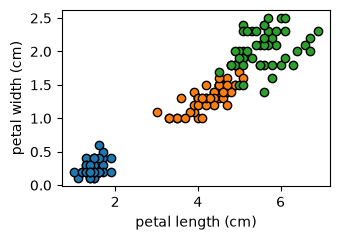

In [8]:
plot(df, clf, feature_importance_df['Feature'].iloc[:2].tolist())  # plot the 2 most important features

# `petal` vs `sepal`

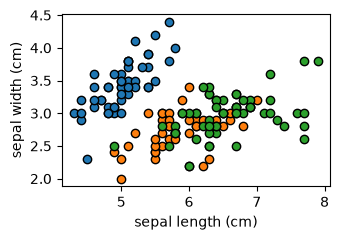

In [9]:
plot(df, clf, feature_importance_df['Feature'].iloc[2:].tolist())  # plot the 2 lest important features

# Tuning `max_depth` 

What do you expect?

In [10]:
#| echo: false
#! output: false
 
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

xlabel = "petal_length"
ylabel = "petal_width"
ctitle = "IRIS"
legend = "species"
figsize = (8,6)
xlim=[0, 7]
ylim=[0, 3]
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# Define the colormap (Tableau)
my_colors=['#1f77b4', '#ff7f0e', '#2ca02c']
tableau_cmap = ListedColormap(my_colors)

def plot_boundary(clf, title, norm=False):
    # Load Iris dataset
    iris = load_iris()

    cxlim = xlim if not norm else [-0.02, 1.02]
    cylim = ylim if not norm else [-0.02, 1.02]

    X = iris.data[:, 2:4]  # Selecting petal width and petal length columns
    y = iris.target
    
    if norm:
      scaler = MinMaxScaler(feature_range=(0, 1))
      X = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
    # Train a classifier
    clf.fit(X_train, y_train)
    # y_pred = clf.predict(X_test)

    # Create a meshgrid for plotting decision boundaries
    x_min, x_max = [cxlim[0] - 0.5, cxlim[1] + 0.5] # X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = [cylim[0] - 0.5, cylim[1] + 0.5] # X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.005), np.arange(y_min, y_max, 0.005))

    # Predict the class for each point in the meshgrid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundaries
    plt.figure(figsize=figsize)
    plt.contour(xx, yy, Z, colors='white', linewidths=1, alpha=0.8)
    plt.contourf(xx, yy, Z, cmap=tableau_cmap, alpha=0.3)

    # Plot the dataset points
    for i, class_name in enumerate(target_names):
        class_data = X_train[y_train == i]
        plt.scatter(class_data[:, 0], class_data[:, 1], label=class_name, marker='o', color=my_colors[i], edgecolor='k', s=70)
        class_data = X_test[y_test == i]
        plt.scatter(class_data[:, 0], class_data[:, 1], label=class_name + " (test)", marker='^', color=my_colors[i], edgecolor='k', s=70)

    legend_elements = [
                      # Line2D([0], [0], marker='s', color='w', label=' ', markerfacecolor='w', markeredgecolor='w', markersize=10),
                      Line2D([0], [0], marker=None, color='w', label=legend, markerfacecolor='w', markeredgecolor='w', markersize=10),
                      Line2D([0], [0], marker='o',  color='w', label='Setosa', markerfacecolor='tab:blue', markeredgecolor='w', markersize=10),
                      Line2D([0], [0], marker='o',  color='w', label='Versicolor', markerfacecolor='tab:orange', markeredgecolor='w', markersize=10),
                      Line2D([0], [0], marker='o',  color='w', label='Virginica', markerfacecolor='tab:green', markeredgecolor='w', markersize=10),
                      
                      Line2D([0], [0], marker=None, color='w', label='Set',      markerfacecolor=None,     markeredgecolor='w', markersize=10),
                      Line2D([0], [0], marker='o',  color='w', label='Training', markerfacecolor='white',  markeredgecolor='black', markersize=10),
                      Line2D([0], [0], marker='^',  color='w', label='Test',     markerfacecolor='white',  markeredgecolor='black', markersize=10),
                ]

    plt.legend(handles=legend_elements, loc=2, ncol=2)

    plt.xlim(cxlim)
    plt.ylim(cylim)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(ctitle)
    # plt.legend(title=legend, loc=2)

    return clf

# Decision boundaries: `max_depth=1`

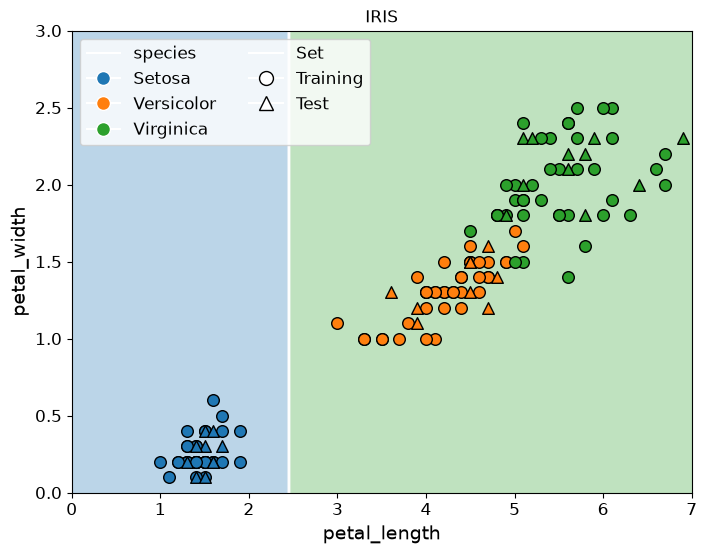

In [11]:
tree = plot_boundary(DecisionTreeClassifier(max_depth=1, random_state=seed), "decisiontree_cplot")

# Decision boundaries: `max_depth=2`

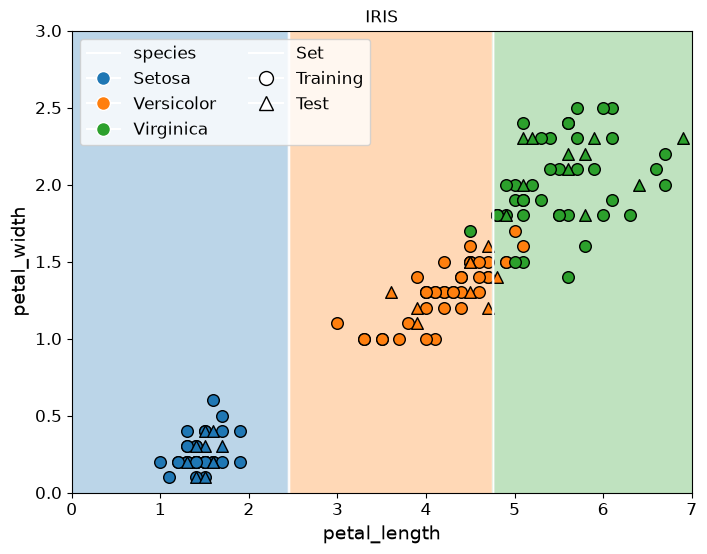

In [12]:
tree = plot_boundary(DecisionTreeClassifier(max_depth=2, random_state=seed), "decisiontree_cplot")

# Decision boundaries: `max_depth=2` (changing the random seed)

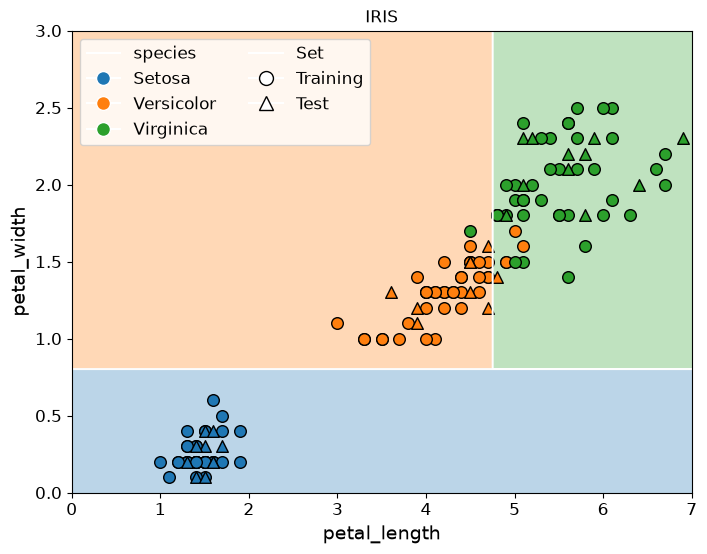

In [13]:
tree = plot_boundary(DecisionTreeClassifier(max_depth=2, random_state=1), "decisiontree_cplot")

# Decision boundaries: `max_depth=3`

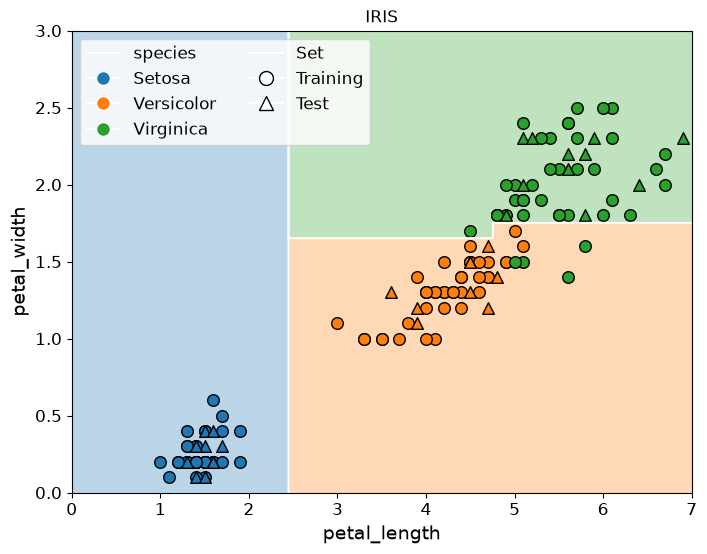

In [14]:
tree = plot_boundary(DecisionTreeClassifier(max_depth=3, random_state=seed), "decisiontree_cplot")

# Decision boundaries: `max_depth=6`

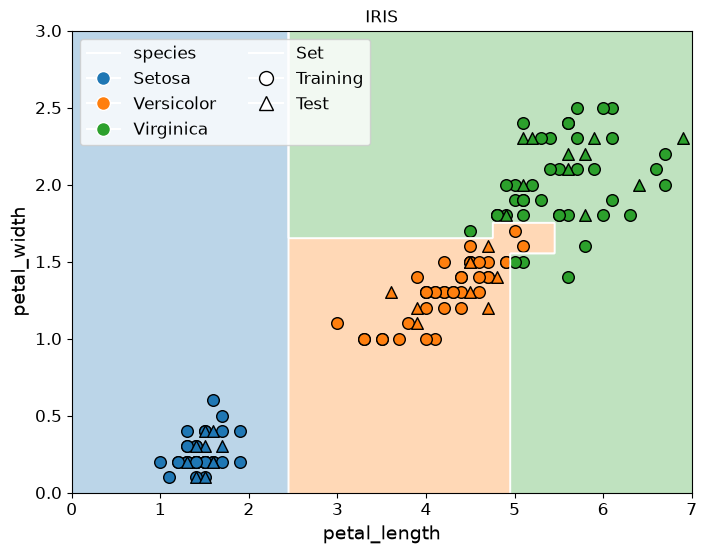

In [15]:
tree = plot_boundary(DecisionTreeClassifier(max_depth=6, random_state=seed), "decisiontree_cplot")

# Hyperparameter optimization

**Hyper-parameters** are parameters that are not directly learnt within estimators.

- In scikit-learn they are passed as arguments to the constructor of the estimator classes
- How do we tune hyperparameters?


# Hyperparameter optimization

Hyper-parameters: parameters that are not directly learnt within estimators

- In scikit-learn they are passed as arguments to the constructor of the estimator classes
- Any parameter provided when constructing an estimator may be optimized

```python
estimator.get_params()
```

A search consists of:

- an estimator $(\checkmark)$
- a score function $(\checkmark)$
- a parameter space
- a method for searching or sampling candidates
- a cross-validation scheme

# Parameter space (or search space)

**Search Space**: space where each dimension represents a hyperparameter and each point represents one model configuration.

Consider the following hyperparameters of a random forest:

- `max_depth`: maximum depth of a single tree, `min_samples_leaf`: minimum number of samples required to be at a leaf node

Assume that the domain of the two parameters is the following:

- `max_depth` $\in [1, 10]$, `min_samples_leaf` $\in [2, 20]$

Then, our 2D-search space is

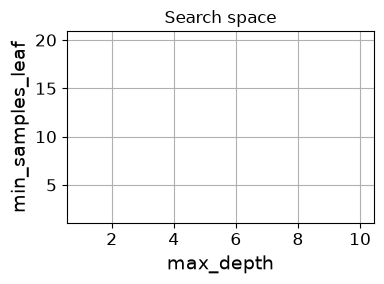

In [16]:
#| echo: false

# Creating a hypothetical 2D dataset of max_depth and min_samples_split
max_depth_range = np.linspace(1, 10, 10)  # 10 values for max_depth
min_samples_split_range = np.linspace(2, 20, 10)  # 10 values for min_samples_split
# Generate grid points for grid search
grid_max_depth, grid_min_split = np.meshgrid(max_depth_range, min_samples_split_range)
grid_points = np.c_[grid_max_depth.ravel(), grid_min_split.ravel()]
# Plotting the grid search and random search scatter plots
fig, ax1 = plt.subplots(1, 1, figsize=(4, 3))
# Scatter plot for grid search
ax1.scatter(grid_points[:, 0], grid_points[:, 1], color='white', label='Grid Search Points')
ax1.set_title('Search space')
ax1.set_xlabel('max_depth')
ax1.set_ylabel('min_samples_leaf')
ax1.grid(True)
fig.tight_layout()

# Hyper-parameter tuning

There are many search algorithms:

- *Grid search* exhaustively tries every combination of the provided hyper-parameter values in order to find the best model.
- (Pure) *Random search* samples from the entirety of the search space
    - Such optimization methods are also known as direct-search, derivative-free, or black-box methods. 
    
    > If good parts of the search space occupy 5% of the volume the chances of hitting a good configuration is 5%.
    >
    > The probability of finding at least one good configuration is above 95% after trying out 60 configurations ($1 − 0.95^{60} = 0.953 > 0.95$)

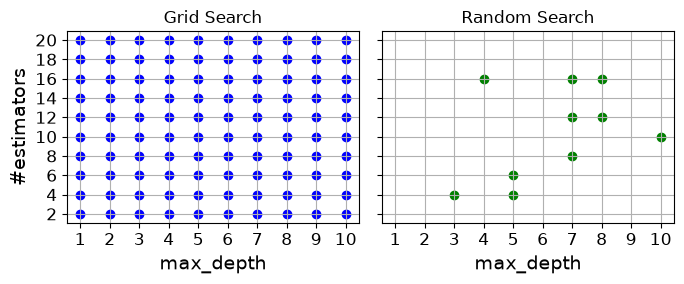

In [17]:
#| echo: false

# Creating a hypothetical 2D dataset of max_depth and min_samples_split
max_depth_range = np.linspace(1, 10, 10)  # 10 values for max_depth
min_samples_split_range = np.linspace(2, 20, 10)  # 10 values for min_samples_split

# Generate grid points for grid search
grid_max_depth, grid_min_split = np.meshgrid(max_depth_range, min_samples_split_range)
grid_points = np.c_[grid_max_depth.ravel(), grid_min_split.ravel()]

np.random.seed(seed)
# Randomly sample points for random search
random_points = np.array([np.random.choice(max_depth_range, 10), np.random.choice(min_samples_split_range, 10)]).T

# Plotting the grid search and random search scatter plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharex=True, sharey=True)

# Scatter plot for grid search
ax1.scatter(grid_points[:, 0], grid_points[:, 1], color='blue', label='Grid Search Points')
ax1.set_title('Grid Search')
ax1.set_xlabel('max_depth')
ax1.set_ylabel('#estimators')
ax1.grid(True)

# Scatter plot for random search
ax2.scatter(random_points[:, 0], random_points[:, 1], color='green', label='Random Search Points')
ax2.set_title('Random Search')
ax2.set_xlabel('max_depth')
ax2.set_yticks(list(range(2, 22, 2)))
ax2.set_xticks(list(range(1, 11)))
ax2.grid(True)
fig.tight_layout()

# Cross validation

How do we test the hyperparameter configurations?

:::: {.columns}
::: {.column width=50%}

![](img/remote/sklearn-grid-search-workflow.png)

:::
::: {.column width=50%}

![](img/remote/sklearn-grid-search-cross-validation.png)

:::
::::

## Example of cross correlation

![](img/remote/github-asset-d3a1aff6.png)

# Plotting training and cross-validation accuracy


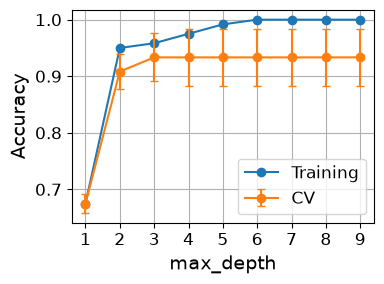

In [18]:
#| echo: false

# Prepare to store max_depth values and corresponding accuracies
max_depths = range(1, 10)
train_accuracies, cv_accuracies, cv_stds = [], [], []
for max_depth in max_depths:  # Train decision trees with increasing max_depth
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=seed)
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))  # Compute accuracy for training set
    cv_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="accuracy")  # Evaluate with CV on the training set
    train_accuracies.append(train_acc)
    cv_accuracies.append(cv_scores.mean())
    cv_stds.append(cv_scores.std())
# Plot accuracies
plt.figure(figsize=(4, 3))
plt.plot(max_depths, train_accuracies, label="Training", marker="o")
plt.errorbar(max_depths, cv_accuracies, yerr=cv_stds, label="CV", marker="o", capsize=3)
plt.xticks(max_depths)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()


# Random forest

Best Parameters from Random Search: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 17, 'n_estimators': 152}
Best Cross-validation Accuracy: 0.95 Test Set Accuracy with Best Parameters: 1.0


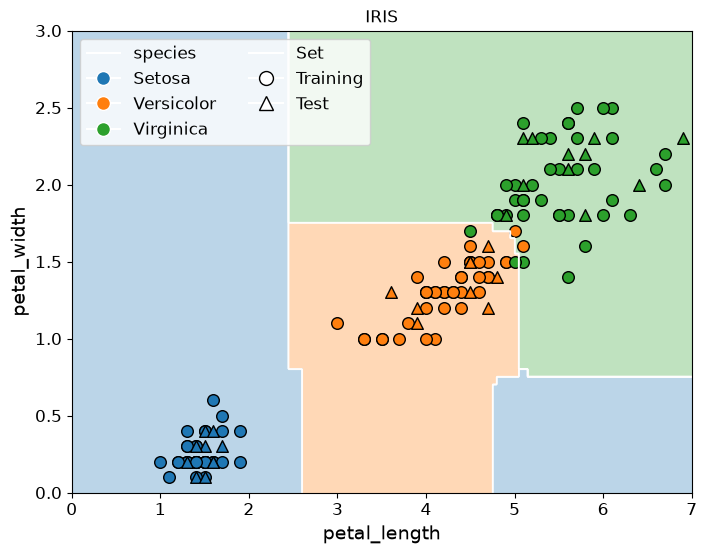

In [19]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
rf = RandomForestClassifier(random_state=seed)  # Define a Random Forest Classifier
param_dist = {  # Set up the parameter grid for random search
    'n_estimators': randint(2, 200),        # Number of trees in the forest
    'max_depth': randint(2, 20),            # Maximum depth of the tree
    'min_samples_split': randint(2, 20),    # Minimum number of samples to split a node
    'min_samples_leaf': randint(1, 20),     # Minimum number of samples in a leaf node
}
random_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=50, scoring='accuracy', cv=cv, random_state=seed, n_jobs=-1)  # Setup RandomizedSearchCV
random_search.fit(X_train, y_train)  # Fit the random search model
print("Best Parameters from Random Search:", random_search.best_params_)  # Output the best parameters 
best_rf = random_search.best_estimator_
test_accuracy = best_rf.score(X_test, y_test)  # Evaluate the model with the best parameters on the test set
print("Best Cross-validation Accuracy:", random_search.best_score_, "Test Set Accuracy with Best Parameters:", test_accuracy)  # Output the best score
forest = plot_boundary(best_rf, "rf_cplot")

# k-Nearest Neighbors

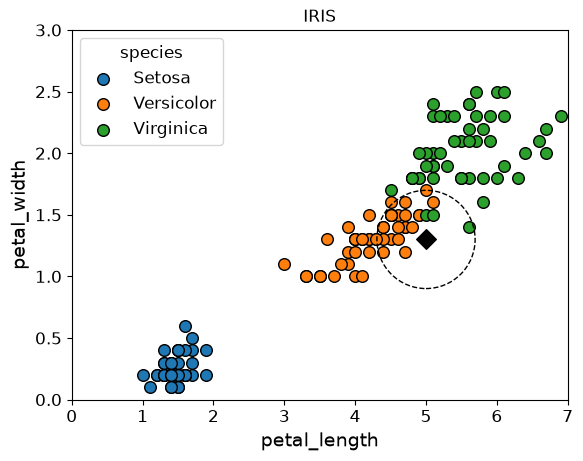

In [20]:
#| echo: false

X = iris.data[:, 2:4]  # Selecting petal width and petal length columns
y = iris.target
# Plot the dataset points
for i, class_name in enumerate(target_names):
    class_data = X[y == i]
    plt.scatter(class_data[:, 0], class_data[:, 1], label=class_name, edgecolor='k', s=70)

plt.xlim(xlim)
plt.ylim(ylim)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(ctitle)
plt.legend(title=legend, loc=2)

# for ext in ["svg", "pdf", "jpg"]:
#   plt.savefig(f'iris.{ext}')

plt.scatter(5, 1.3, s=5000, facecolors='none', edgecolors='black', linestyle='--')
plt.scatter(5, 1.3, s=100, marker="D", facecolors='black', edgecolors='black')

# for ext in ["svg", "pdf", "jpg"]:
#   plt.savefig(f'knn.{ext}')

# Tuning `k` 

What do you expect?

# Decision boundaries: `k=1` (no normalization)

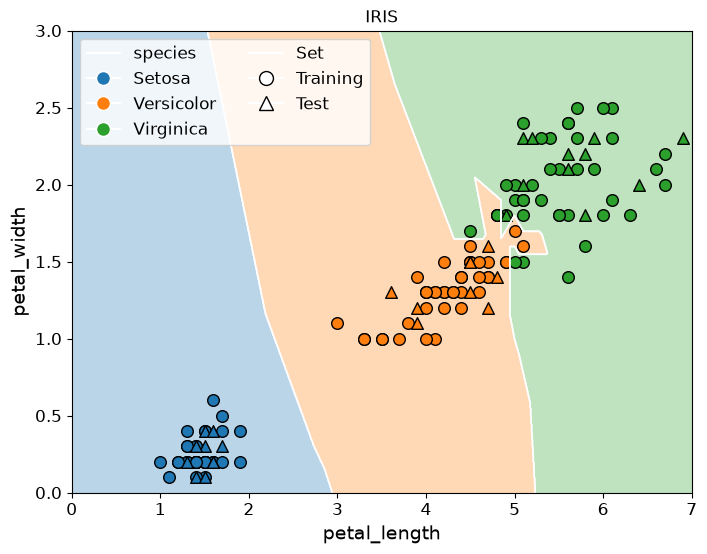

In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn = plot_boundary(KNeighborsClassifier(n_neighbors=1), "knn_cplot", norm=False)

# Decision boundaries: `k=1` (min-max normalization)

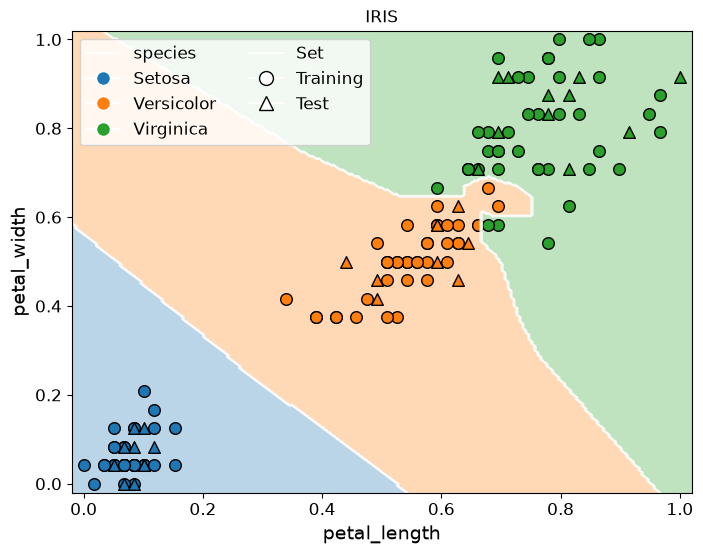

In [22]:
knn = plot_boundary(KNeighborsClassifier(n_neighbors=1), "knn_cplot", norm=True)

# Decision boundaries: `k=10` (min-max normalization)

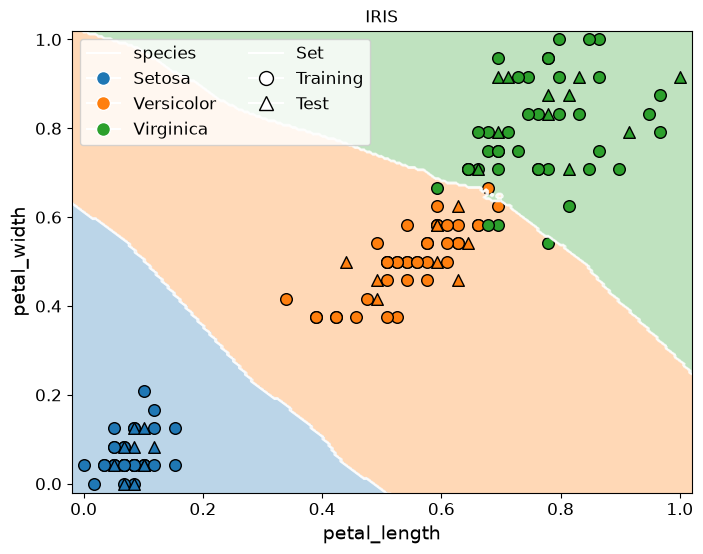

In [23]:
knn = plot_boundary(KNeighborsClassifier(n_neighbors=10), "knn_cplot", norm=True)

# Plotting training and cross-validation accuracy


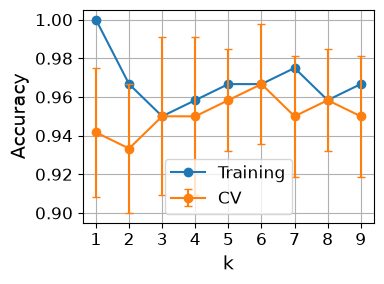

In [24]:
# Prepare to store k values and corresponding accuracies
k_s = range(1, 10)
train_accuracies, cv_accuracies, cv_stds = [], [], []
for k in k_s:  # Train k-NN classifiers with increasing k
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, knn.predict(X_train))  # Compute accuracy for training set
    cv_scores = cross_val_score(knn, X_train, y_train, cv=cv, scoring="accuracy")  # Evaluate with CV on the training set
    train_accuracies.append(train_acc)
    cv_accuracies.append(cv_scores.mean())
    cv_stds.append(cv_scores.std())
# Plot accuracies
plt.figure(figsize=(4, 3))
plt.plot(k_s, train_accuracies, label="Training", marker="o")
plt.errorbar(k_s, cv_accuracies, yerr=cv_stds, label="CV", marker="o", capsize=3)
plt.xticks(k_s)
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()


# Perceptron

Perceptron is binary classifier.
How can we use it in Iris? 

# One Versus All

:::: {.columns}
::: {.column width="60%"}

One Versus All (OVA) strategy for multiclasses

- OVA provides a way to use binary classification for a series of yes or no predictions across multiple possible labels.
- Given a classification problem with N possible solutions, a OVA solution consists of N separate binary classifiers—one binary classifier for each possible outcome.
- During training, the model runs through a sequence of binary classifiers, training each to answer a separate classification question.
- Finally, pick the prediction of a non -zero class which is the most certain and use argmax of these score(class index with largest score) is then used to predict a class.

:::
::: {.column width="40%"}

For example, given a picture of a piece of fruit, four different recognizers might be trained, each answering a different yes/no question:

    Is this image an apple?
    Is this image an orange?
    Is this image a banana?
    Is this image a grape?

![](img/remote/google-mlcc-one-vs-all-binary-classifiers.png)

:::
::::




# Perceptron

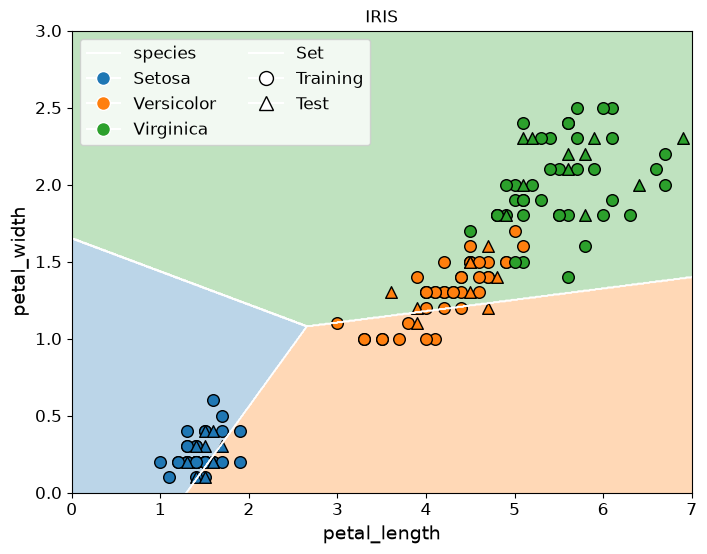

In [25]:
from sklearn.linear_model import Perceptron

perceptron = plot_boundary(Perceptron(random_state=seed), "perceptron_cplot")

# Perceptron: changing the seed

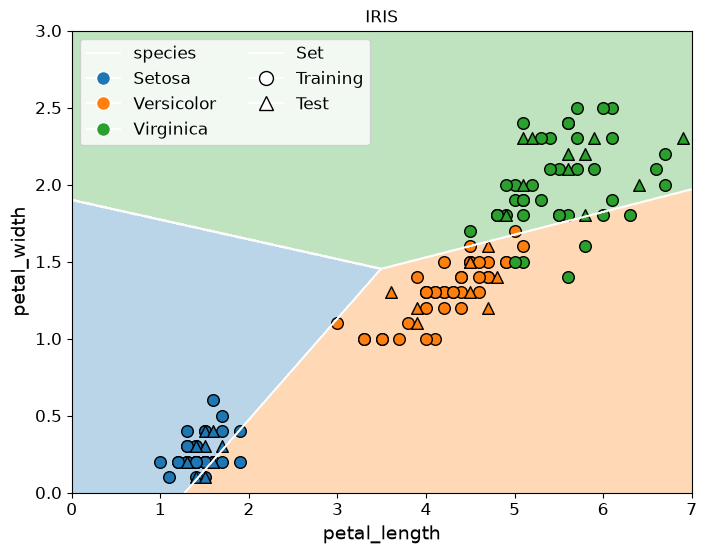

In [26]:
perceptron = plot_boundary(Perceptron(random_state=1), "perceptron_cplot")

# Multi-layer perceptron

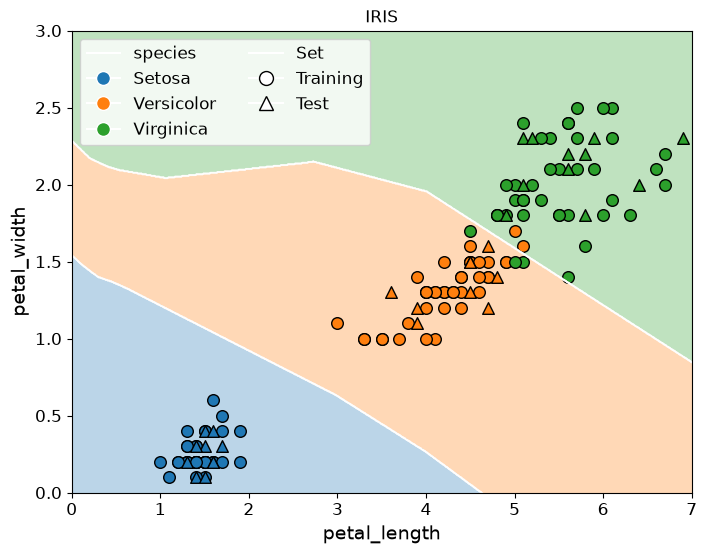

In [27]:
from sklearn.neural_network import MLPClassifier

mlp = plot_boundary(MLPClassifier(hidden_layer_sizes=(10, 20), random_state=seed, max_iter=1000), "mlp_cplot")

# Exercise

1. Load the `wine` dataset from `sklearn`
1. Train a decision tree
1. ... try different configurations of hyperparameters
1. What is your best accuracy?
1. What are the most relevant features?